  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
mlxtend 0.23.4 requires scipy>=1.2.1, which is not installed.
umap-learn 0.5.12 requires scikit-learn>=1.6, which is not installed.
umap-learn 0.5.12 requires scipy>=1.3.1, which is not installed.
shap 0.51.0 requires scikit-learn, which is not installed.
shap 0.51.0 requires scipy, which is not installed.
mizani 0.13.5 requires scipy>=1.8.0, which is not installed.
sentence-transformers 5.4.1 requires scikit-learn>=0.22.0, which is not installed.
sentence-transformers 5.4.1 requires scipy>=1.0.0, which is not installed.
clarabel 0.11.1 requires scipy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
umap-learn 0.5.12 requires scikit-learn>=1.6, which is not installed.
shap 0.51.0 requires scikit-learn, which is not installed.
sentence-transformers 5.4.1 requires scikit-learn>=0.22.0, which is not installed.
libpysal 4.14.1 requires scikit-learn>=1.4.0, which is not installed.
librosa 0.11.0 requires scikit-learn>=1.1.0, which is not installed.
yellowbrick 1.5 requires scikit-learn>=1.0.0, which is not installed.
pynndescent 0.6.0 requires scikit-learn>=0.18, which is not installed.
tsfresh 0.21.1 requires scikit-learn>=0.22.0, which is not installed.
spopt 0.7.0 requires scikit-learn>=1.4.0, which is not installed.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, which is not installed.
esda 2.9.0 requires scikit-learn>=1.4, which is

Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:01<00:00, 100.84it/s]
Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7cde40f4f2e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: 


Calculando métricas estruturais...


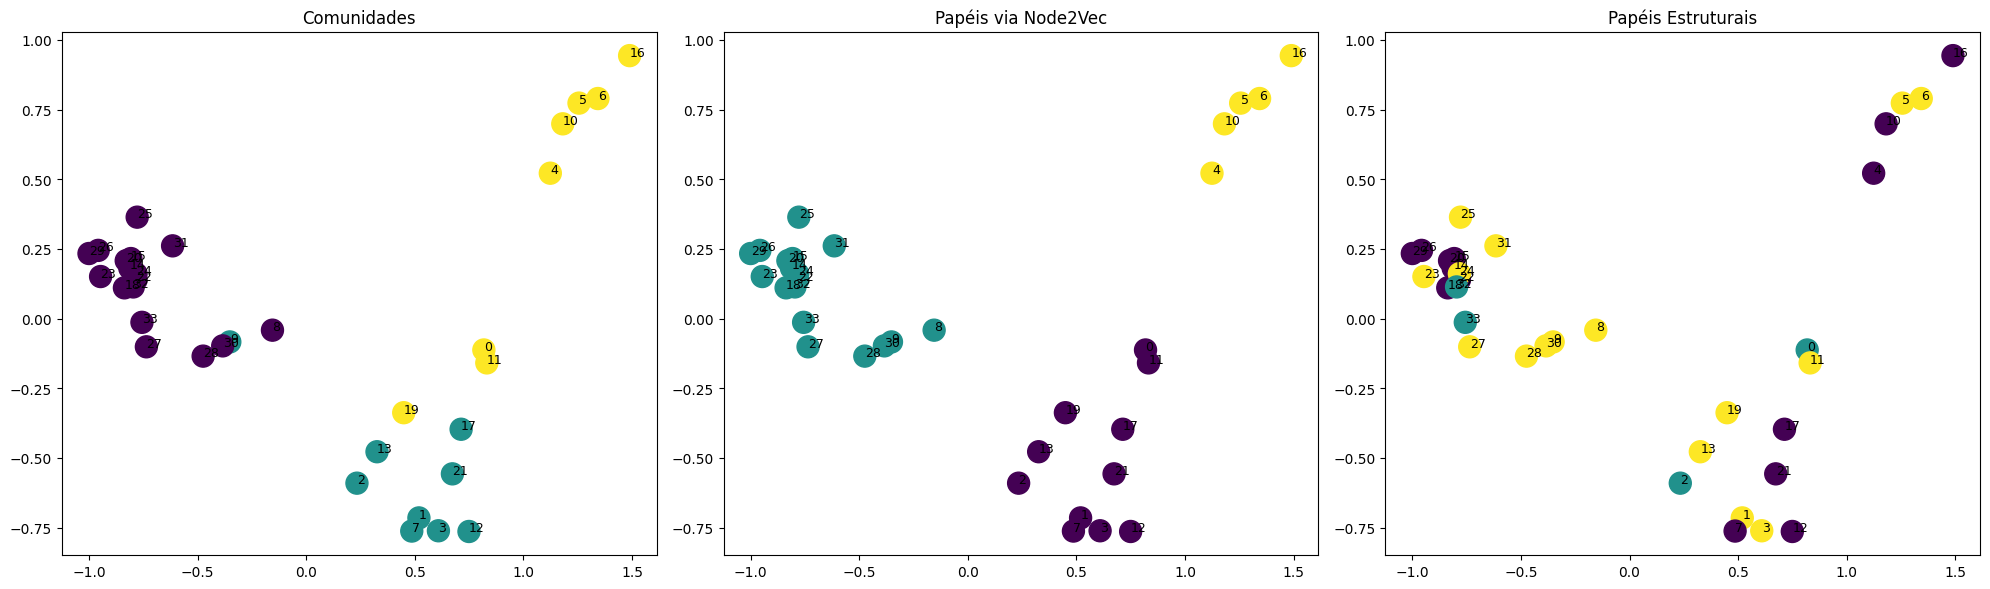

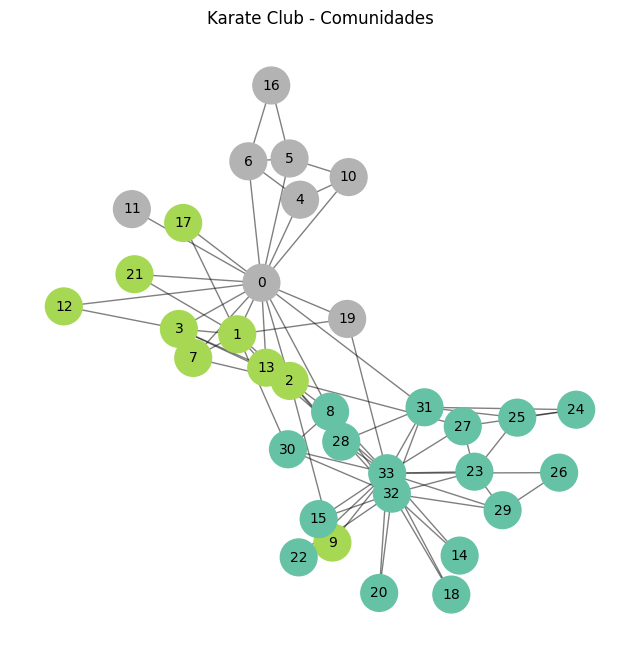

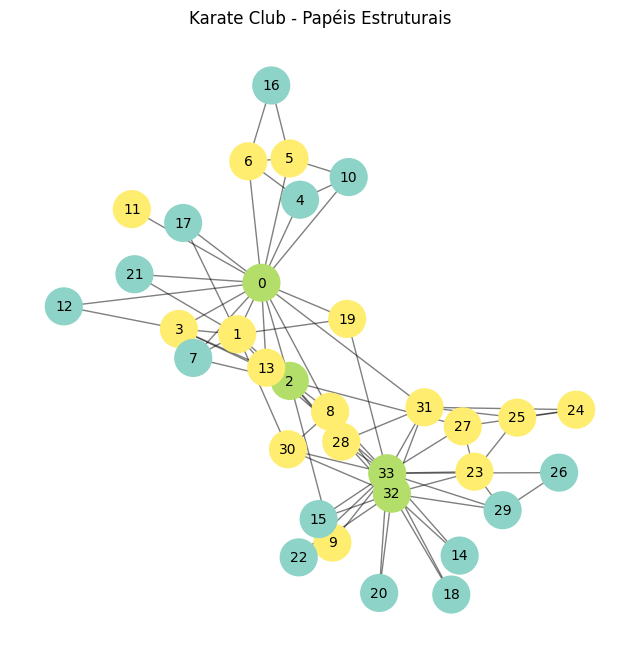


ANÁLISE DOS PAPÉIS

ROLE 0
Nós: [4, 7, 10, 12, 14, 15, 16, 17, 18, 20, 21, 22, 26, 29]
Degree médio: 2.43
Betweenness médio: 0.0003

ROLE 1
Nós: [0, 2, 32, 33]
Degree médio: 13.75
Betweenness médio: 0.2577

ROLE 2
Nós: [1, 3, 5, 6, 8, 9, 11, 13, 19, 23, 24, 25, 27, 28, 30, 31]
Degree médio: 4.19
Betweenness médio: 0.0288

TOP NÓS IMPORTANTES
Nó 33 | Degree=17 | Comunidade=0 | Role=1
Nó 0 | Degree=16 | Comunidade=2 | Role=1
Nó 32 | Degree=12 | Comunidade=0 | Role=1
Nó 2 | Degree=10 | Comunidade=1 | Role=1
Nó 1 | Degree=9 | Comunidade=1 | Role=2
Nó 3 | Degree=6 | Comunidade=1 | Role=2
Nó 31 | Degree=6 | Comunidade=0 | Role=2
Nó 8 | Degree=5 | Comunidade=0 | Role=2
Nó 13 | Degree=5 | Comunidade=1 | Role=2
Nó 23 | Degree=5 | Comunidade=0 | Role=2

COMUNIDADE VS ROLE
[[7. 2. 8.]
 [4. 1. 4.]
 [3. 1. 4.]]


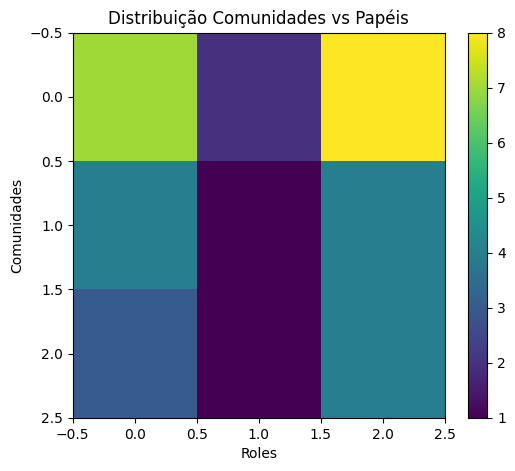

In [1]:
!pip install --upgrade pip setuptools wheel -q
!pip uninstall -y -q node2vec gensim scipy numpy scikit-learn
!pip install numpy==1.26.4
!pip install scipy==1.12.0 -q
!pip install scikit-learn==1.4.2 -q
!pip install gensim==4.4.0 -q
!pip install node2vec==0.5.0 -q

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from node2vec import Node2Vec
from networkx.algorithms.community import greedy_modularity_communities

# =========================================================
# 1. GRAFO ZACHARY KARATE CLUB
# =========================================================

G = nx.karate_club_graph()

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

# =========================================================
# 2. DETECÇÃO DE COMUNIDADES
# =========================================================

communities = list(
    greedy_modularity_communities(G)
)

community_labels = {}

for idx, comm in enumerate(communities):

    for node in comm:
        community_labels[node] = idx

print("\nQuantidade de comunidades:", len(communities))

# =========================================================
# 3. NODE2VEC EMBEDDINGS
# =========================================================

node2vec = Node2Vec(
    G,
    dimensions=16,
    walk_length=20,
    num_walks=200,
    workers=1,
    seed=42
)

model = node2vec.fit(
    window=5,
    min_count=1
)

embeddings = []

for node in G.nodes():

    embeddings.append(
        model.wv[str(node)]
    )

embeddings = np.array(embeddings)

# =========================================================
# 4. ROLES VIA NODE2VEC + KMEANS
# =========================================================

kmeans_embed = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

role_labels_node2vec = (
    kmeans_embed.fit_predict(embeddings)
)

# =========================================================
# 5. FEATURES ESTRUTURAIS (ROLX SIMPLIFICADO)
# =========================================================

print("\nCalculando métricas estruturais...")

betweenness = nx.betweenness_centrality(G)

closeness = nx.closeness_centrality(G)

pagerank = nx.pagerank(G)

features = []

for node in G.nodes():

    degree = G.degree(node)

    clustering = nx.clustering(G, node)

    features.append([
        degree,
        clustering,
        betweenness[node],
        closeness[node],
        pagerank[node]
    ])

features = np.array(features)

scaler = StandardScaler()

features_scaled = scaler.fit_transform(
    features
)

# =========================================================
# 6. CLUSTERIZAÇÃO DOS PAPÉIS ESTRUTURAIS
# =========================================================

kmeans_roles = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

role_labels_structural = (
    kmeans_roles.fit_predict(features_scaled)
)

# =========================================================
# 7. PCA DOS EMBEDDINGS
# =========================================================

pca = PCA(n_components=2)

embed_2d = pca.fit_transform(
    embeddings
)

# =========================================================
# 8. VISUALIZAÇÃO DOS EMBEDDINGS
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

# ---------------------------------------------------------
# Comunidades
# ---------------------------------------------------------

axes[0].scatter(
    embed_2d[:, 0],
    embed_2d[:, 1],
    c=[community_labels[n] for n in G.nodes()],
    s=250
)

for i, node in enumerate(G.nodes()):

    axes[0].text(
        embed_2d[i, 0],
        embed_2d[i, 1],
        str(node),
        fontsize=9
    )

axes[0].set_title(
    "Comunidades"
)

# ---------------------------------------------------------
# Roles via Node2Vec
# ---------------------------------------------------------

axes[1].scatter(
    embed_2d[:, 0],
    embed_2d[:, 1],
    c=role_labels_node2vec,
    s=250
)

for i, node in enumerate(G.nodes()):

    axes[1].text(
        embed_2d[i, 0],
        embed_2d[i, 1],
        str(node),
        fontsize=9
    )

axes[1].set_title(
    "Papéis via Node2Vec"
)

# ---------------------------------------------------------
# Roles Estruturais
# ---------------------------------------------------------

axes[2].scatter(
    embed_2d[:, 0],
    embed_2d[:, 1],
    c=role_labels_structural,
    s=250
)

for i, node in enumerate(G.nodes()):

    axes[2].text(
        embed_2d[i, 0],
        embed_2d[i, 1],
        str(node),
        fontsize=9
    )

axes[2].set_title(
    "Papéis Estruturais"
)

plt.tight_layout()
plt.show()

# =========================================================
# 9. GRAFO COLORIDO POR COMUNIDADE
# =========================================================

plt.figure(figsize=(8, 8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=[
        community_labels[n]
        for n in G.nodes()
    ],
    node_size=700,
    cmap=plt.cm.Set2
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title(
    "Karate Club - Comunidades"
)

plt.axis("off")
plt.show()

# =========================================================
# 10. GRAFO COLORIDO POR PAPEL ESTRUTURAL
# =========================================================

plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=role_labels_structural,
    node_size=700,
    cmap=plt.cm.Set3
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title(
    "Karate Club - Papéis Estruturais"
)

plt.axis("off")
plt.show()

# =========================================================
# 11. ANÁLISE DOS PAPÉIS
# =========================================================

nodes = list(G.nodes())

print("\n==============================")
print("ANÁLISE DOS PAPÉIS")
print("==============================")

for role in np.unique(
    role_labels_structural
):

    idxs = np.where(
        role_labels_structural == role
    )[0]

    role_nodes = [
        nodes[i]
        for i in idxs
    ]

    avg_degree = np.mean([
        G.degree(n)
        for n in role_nodes
    ])

    avg_bet = np.mean([
        betweenness[n]
        for n in role_nodes
    ])

    print(f"\nROLE {role}")

    print(
        "Nós:",
        role_nodes
    )

    print(
        "Degree médio:",
        round(avg_degree, 2)
    )

    print(
        "Betweenness médio:",
        round(avg_bet, 4)
    )

# =========================================================
# 12. NÓS MAIS IMPORTANTES
# =========================================================

degree_dict = dict(G.degree())

top_hubs = sorted(
    degree_dict.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\n==============================")
print("TOP NÓS IMPORTANTES")
print("==============================")

for node, deg in top_hubs[:10]:

    print(
        f"Nó {node} | "
        f"Degree={deg} | "
        f"Comunidade={community_labels[node]} | "
        f"Role={role_labels_structural[node]}"
    )

# =========================================================
# 13. MATRIZ COMUNIDADE VS ROLE
# =========================================================

num_communities = len(communities)

num_roles = len(
    np.unique(role_labels_structural)
)

matrix = np.zeros(
    (num_communities, num_roles)
)

for node in G.nodes():

    c = community_labels[node]

    r = role_labels_structural[node]

    matrix[c, r] += 1

print("\n==============================")
print("COMUNIDADE VS ROLE")
print("==============================")

print(matrix)

plt.figure(figsize=(6, 5))

plt.imshow(
    matrix,
    aspect="auto"
)

plt.colorbar()

plt.xlabel("Roles")
plt.ylabel("Comunidades")

plt.title(
    "Distribuição Comunidades vs Papéis"
)

plt.show()